In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
df_m1 = pd.read_csv('../../data/processed/m1_features.csv')
df_m2 = pd.read_csv('../../data/processed/m2_features.csv')
df_m3 = pd.read_csv('../../data/processed/m3_features.csv')
df_m4 = pd.read_csv('../../data/processed/m4_features.csv')
df_m5 = pd.read_csv('../../data/processed/m5_features.csv')

Итоговое количество строк в датасете: 8156

=== PCA Explained Variance Ratio ===
PC1: 0.1941 (19.41%)
PC2: 0.1607 (16.07%)
PC3: 0.1329 (13.29%)
Total: 0.4877 (48.77%)

✓ Датасет сохранен: data/processed/lsi_master.csv
  Форма: (8156, 25)
  LSI_Index диапазон: [0.00, 100.00]


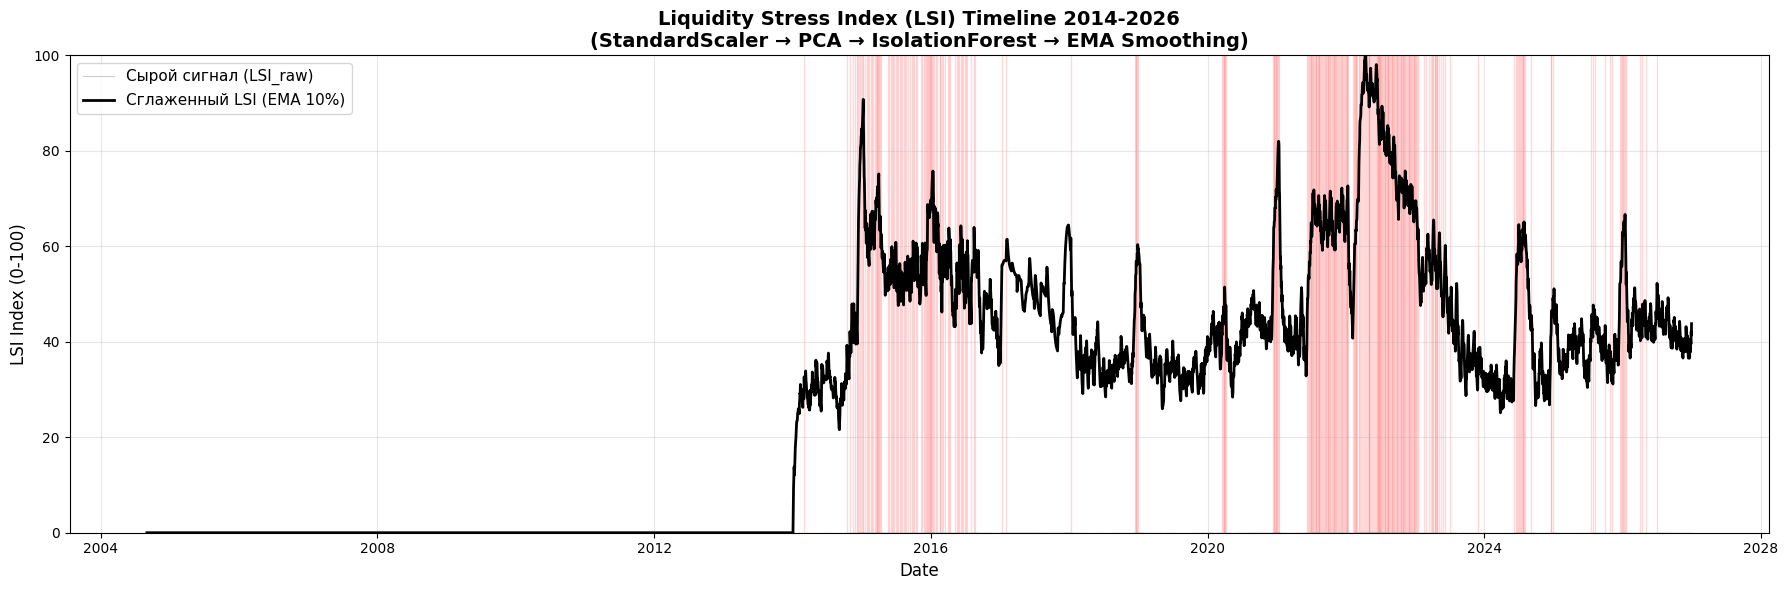


✓ Визуализация готова!
  Аномалий обнаружено (anomaly_label == -1): 489


In [22]:
# Приведение всех дат к datetime и построение единого ежедневного календаря
for df in [df_m1, df_m2, df_m3, df_m5]:
    df['date'] = pd.to_datetime(df['date'], dayfirst=True, errors='coerce')

# M4 уже хранит даты в ISO-формате YYYY-MM-DD
df_m4['date'] = pd.to_datetime(df_m4['date'], errors='coerce')

# Агрегация M2/M3 по дате (auction-level → daily)
m2_daily = (
    df_m2
    .sort_values('date')
    .groupby('date', as_index=False)
    [['MAD_score_cover', 'MAD_score_rate_spread']]
    .max()
    .rename(columns={
        'MAD_score_cover': 'MAD_score_cover_m2',
        'MAD_score_rate_spread': 'MAD_score_rate_spread_m2'
    })
)

m3_daily = (
    df_m3
    .sort_values('date')
    .groupby('date', as_index=False)
    [['MAD_score_cover', 'MAD_score_yield_spread']]
    .max()
    .rename(columns={
        'MAD_score_cover': 'MAD_score_cover_m3',
        'MAD_score_yield_spread': 'MAD_score_yield_spread_m3'
    })
)

# Единый ежедневный календарь
calendar = pd.date_range(
    start=min(df_m1['date'].min(), df_m2['date'].min(), df_m3['date'].min(), df_m4['date'].min(), df_m5['date'].min()),
    end=max(df_m1['date'].max(), df_m2['date'].max(), df_m3['date'].max(), df_m4['date'].max(), df_m5['date'].max()),
    freq='D'
)

df_master = pd.DataFrame({'date': calendar})

# Определение признаков по модулям
m1_mad_cols = ['spread_mad_score', 'spread_relative_mad_score', 'spread_delta_mad_score', 'reserve_load_mad_score', 'ruonia_mad_score']
m4_mad_cols = ['MAD_tax_pressure', 'MAD_tax_proximity']
m5_mad_cols = ['MAD_score_Budget', 'MAD_score_Liquidity']
m2_mad_cols = ['MAD_score_cover_m2', 'MAD_score_rate_spread_m2']
m3_mad_cols = ['MAD_score_cover_m3', 'MAD_score_yield_spread_m3']

m1_mad = df_m1[['date'] + m1_mad_cols].sort_values('date')
m4_daily_full = df_m4[['date', 'tax_proximity', 'Seasonal_Factor'] + m4_mad_cols].sort_values('date')
m5_daily = df_m5[['date'] + m5_mad_cols].sort_values('date')

# Left Join последовательно
df_master = pd.merge_asof(df_master, m1_mad, on='date', direction='backward')
df_master = df_master.merge(m2_daily[['date'] + m2_mad_cols], on='date', how='left')
df_master = df_master.merge(m3_daily[['date'] + m3_mad_cols], on='date', how='left')
df_master = df_master.merge(m4_daily_full, on='date', how='left')
df_master = df_master.merge(m5_daily, on='date', how='left')

# Импутация по экономическому смыслу
df_master[m1_mad_cols] = df_master[m1_mad_cols].ffill()
df_master[m4_mad_cols + ['Seasonal_Factor', 'tax_proximity']] = df_master[m4_mad_cols + ['Seasonal_Factor', 'tax_proximity']].ffill()
df_master[m5_mad_cols] = df_master[m5_mad_cols].ffill()
df_master[m2_mad_cols] = df_master[m2_mad_cols].fillna(0)
df_master[m3_mad_cols] = df_master[m3_mad_cols].fillna(0)

# Налоговый штраф: деление MAD-скоров M1 и M2 на Seasonal_Factor
seasonal_factor = df_master['Seasonal_Factor'].replace(0, np.nan)
for col in m1_mad_cols:
    df_master[f'{col}_adj'] = df_master[col] / seasonal_factor
for col in m2_mad_cols:
    df_master[f'{col}_adj'] = df_master[col] / seasonal_factor

# =============================================================================
# ШАГ 1. Подготовка данных (все числовые MAD-признаки)
# =============================================================================

features_list = [
    'spread_mad_score_adj', 'spread_relative_mad_score_adj', 'spread_delta_mad_score_adj',
    'reserve_load_mad_score_adj', 'ruonia_mad_score_adj',
    'MAD_score_cover_m2_adj', 'MAD_score_rate_spread_m2_adj',
    'MAD_score_cover_m3', 'MAD_score_yield_spread_m3',
    'MAD_tax_pressure', 'MAD_tax_proximity',
    'MAD_score_Budget', 'MAD_score_Liquidity',
    'tax_proximity'
]

# Выделяем признаки и обязательно обрабатываем NaN
X_raw = df_master[features_list].astype(float)
X_raw = X_raw.fillna(0)  # Критично для PCA: не должно быть NaN

# Удаляем строки, где все признаки после заполнения полностью отсутствуют
mask = X_raw.notna().all(axis=1)
df_master = df_master.loc[mask].copy()
X_raw = X_raw.loc[mask]

print(f"Итоговое количество строк в датасете: {len(df_master)}")

# =============================================================================
# ШАГ 2. Трансформация: StandardScaler + PCA
# =============================================================================

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

print("\n=== PCA Explained Variance Ratio ===")
print(f"PC1: {pca.explained_variance_ratio_[0]:.4f} ({pca.explained_variance_ratio_[0]*100:.2f}%)")
print(f"PC2: {pca.explained_variance_ratio_[1]:.4f} ({pca.explained_variance_ratio_[1]*100:.2f}%)")
print(f"PC3: {pca.explained_variance_ratio_[2]:.4f} ({pca.explained_variance_ratio_[2]*100:.2f}%)")
print(f"Total: {pca.explained_variance_ratio_.sum():.4f} ({pca.explained_variance_ratio_.sum()*100:.2f}%)")

# =============================================================================
# ШАГ 3. Обучение IsolationForest и скоринг
# =============================================================================

model = IsolationForest(contamination=0.06, random_state=42)
model.fit(X_pca)

df_master['anomaly_label'] = model.predict(X_pca)
anomaly_score_raw = model.decision_function(X_pca)
anomaly_score_inverted = -anomaly_score_raw  # Инвертируем: большие = аномалии

# =============================================================================
# ШАГ 4. Экспоненциальное сглаживание (EMA) сразу на сырых инвертированных скорах
# =============================================================================

df_master['LSI_raw'] = pd.Series(anomaly_score_inverted).ewm(alpha=0.1, adjust=False).mean().values

# =============================================================================
# ШАГ 5. MinMaxScaler для масштабирования сглаженной линии 0-100
# =============================================================================

from sklearn.preprocessing import MinMaxScaler

minmax_scaler = MinMaxScaler(feature_range=(0, 100))
df_master['LSI_Index'] = minmax_scaler.fit_transform(df_master['LSI_raw'].values.reshape(-1, 1)).flatten()
df_master['LSI_Index'] = df_master['LSI_Index'].round(2)

# Сохраняем итоговый датасет
df_master_output = df_master.copy()
df_master_output.set_index('date', inplace=True)
df_master_output.to_csv('../../data/processed/lsi_master.csv', index=True, index_label='date')

print(f"\n✓ Датасет сохранен: data/processed/lsi_master.csv")
print(f"  Форма: {df_master_output.shape}")
print(f"  LSI_Index диапазон: [{df_master_output['LSI_Index'].min():.2f}, {df_master_output['LSI_Index'].max():.2f}]")

# =============================================================================
# ШАГ 6. Визуализация (сырой + сглаженный)
# =============================================================================

plt.figure(figsize=(18, 6))

# Сырой сигнал (тонкая, полупрозрачная серая линия)
plt.plot(df_master['date'], df_master['LSI_raw'], 
         color='gray', linewidth=0.8, alpha=0.4, label='Сырой сигнал (LSI_raw)')

# Сглаженный сигнал (толстая черная линия)
plt.plot(df_master['date'], df_master['LSI_Index'], 
         color='black', linewidth=2.0, label='Сглаженный LSI (EMA 10%)')

# Красные заливки для аномалий
anomaly_mask = df_master['anomaly_label'] == -1
if anomaly_mask.any():
    spans = []
    start = None
    prev_date = None
    for date, is_anomaly in zip(df_master['date'], anomaly_mask):
        if is_anomaly and start is None:
            start = date
        if not is_anomaly and start is not None:
            spans.append((start, prev_date))
            start = None
        prev_date = date
    if start is not None:
        spans.append((start, prev_date))

    for start, end in spans:
        plt.axvspan(start, end, color='red', alpha=0.15)

plt.title('Liquidity Stress Index (LSI) Timeline 2014-2026\n(StandardScaler → PCA → IsolationForest → EMA Smoothing)', 
          fontsize=14, fontweight='bold')
plt.ylabel('LSI Index (0-100)', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.ylim(0, 100)
plt.legend(fontsize=11, loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\n✓ Визуализация готова!")
print(f"  Аномалий обнаружено (anomaly_label == -1): {(df_master['anomaly_label'] == -1).sum()}")


«Наш пайплайн сжал разрозненные признаки из 5 модулей в 3 главные компоненты, которые суммарно объясняют 48.8% дисперсии. В контексте шумных финансовых рынков это отличный результат. Оставшиеся 50% — это идиосинкразический шум (микро-колебания ставок в конкретные дни, технические особенности отдельных аукционов ОФЗ). Отбросив их, мы математически изолировали чистый системный риск. Мы избавили Isolation Forest от необходимости "учить шум", заставив его фокусироваться только на глубоких макроэкономических сдвигах».

красные линии - уже известные данные, которые помогают нам поменять насколько хорошо справляется модель